# Reinforcement Learning

# Setup

In [ ]:
import sys

assert sys.version_info >= (3, 7)

In [ ]:
IS_COLAB = "google.colab" in sys.modules
if IS_COLAB:
    import os
    os.environ["TF_USE_LEGACY_KERAS"] = "1"
    import tf_keras

In [ ]:
from packaging import version
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

# Exercise Solutions

## 1. to 7.

1. Reinforcement Learning is an area of Machine Learning aimed at creating agents capable of taking actions in an environment in a way that maximizes rewards over time. There are many differences between RL and regular supervised and unsupervised learning. Here are a few:
    * In supervised and unsupervised learning, the goal is generally to find patterns in the data and use them to make predictions. In Reinforcement Learning, the goal is to find a good policy.
    * Unlike in supervised learning, the agent is not explicitly given the "right" answer. It must learn by trial and error.
    * Unlike in unsupervised learning, there is a form of supervision, through rewards. We do not tell the agent how to perform the task, but we do tell it when it is making progress or when it is failing.
    * A Reinforcement Learning agent needs to find the right balance between exploring the environment, looking for new ways of getting rewards, and exploiting sources of rewards that it already knows. In contrast, supervised and unsupervised learning systems generally don't need to worry about exploration; they just feed on the training data they are given.
    * In supervised and unsupervised learning, training instances are typically independent (in fact, they are generally shuffled). In Reinforcement Learning, consecutive observations are generally _not_ independent. An agent may remain in the same region of the environment for a while before it moves on, so consecutive observations will be very correlated. In some cases a replay buffer (memory) is used to ensure that the training algorithm gets fairly independent observations.
2. Here are a few possible applications of Reinforcement Learning, other than those mentioned in Chapter 18:
    * Music personalization: The environment is a user's personalized web radio. The agent is the software deciding what song to play next for that user. Its possible actions are to play any song in the catalog (it must try to choose a song the user will enjoy) or to play an advertisement (it must try to choose an ad that the user will be interested in). It gets a small reward every time the user listens to a song, a larger reward every time the user listens to an ad, a negative reward when the user skips a song or an ad, and a very negative reward if the user leaves.
    * Marketing: The environment is your company's marketing department. The agent is the software that defines which customers a mailing campaign should be sent to, given their profile and purchase history (for each customer it has two possible actions: send or don't send). It gets a negative reward for the cost of the mailing campaign, and a positive reward for estimated revenue generated from this campaign.
    * Product delivery: Let the agent control a fleet of delivery trucks, deciding what they should pick up at the depots, where they should go, what they should drop off, and so on. It will get positive rewards for each product delivered on time, and negative rewards for late deliveries.
3. When estimating the value of an action, Reinforcement Learning algorithms typically sum all the rewards that this action led to, giving more weight to immediate rewards and less weight to later rewards (considering that an action has more influence on the near future than on the distant future). To model this, a discount factor is typically applied at each time step. For example, with a discount factor of 0.9, a reward of 100 that is received two time steps later is counted as only 0.9<sup>2</sup> × 100 = 81 when you are estimating the value of the action. You can think of the discount factor as a measure of how much the future is valued relative to the present: if it is very close to 1, then the future is valued almost as much as the present; if it is close to 0, then only immediate rewards matter. Of course, this impacts the optimal policy tremendously: if you value the future, you may be willing to put up with a lot of immediate pain for the prospect of eventual rewards, while if you don't value the future, you will just grab any immediate reward you can find, never investing in the future.
4. To measure the performance of a Reinforcement Learning agent, you can simply sum up the rewards it gets. In a simulated environment, you can run many episodes and look at the total rewards it gets on average (and possibly look at the min, max, standard deviation, and so on).
5. The credit assignment problem is the fact that when a Reinforcement Learning agent receives a reward, it has no direct way of knowing which of its previous actions contributed to this reward. It typically occurs when there is a large delay between an action and the resulting reward (e.g., during a game of Atari's _Pong_, there may be a few dozen time steps between the moment the agent hits the ball and the moment it wins the point). One way to alleviate it is to provide the agent with shorter-term rewards, when possible. This usually requires prior knowledge about the task. For example, if we want to build an agent that will learn to play chess, instead of giving it a reward only when it wins the game, we could give it a reward every time it captures one of the opponent's pieces.
6. An agent can often remain in the same region of its environment for a while, so all of its experiences will be very similar for that period of time. This can introduce some bias in the learning algorithm. It may tune its policy for this region of the environment, but it will not perform well as soon as it moves out of this region. To solve this problem, you can use a replay buffer; instead of using only the most immediate experiences for learning, the agent will learn based on a buffer of its past experiences, recent and not so recent (perhaps this is why we dream at night: to replay our experiences of the day and better learn from them?).
7. An off-policy RL algorithm learns the value of the optimal policy (i.e., the sum of discounted rewards that can be expected for each state if the agent acts optimally) while the agent follows a different policy. Q-Learning is a good example of such an algorithm. In contrast, an on-policy algorithm learns the value of the policy that the agent actually executes, including both exploration and exploitation.

## 8.
_Exercise: Use policy gradients to solve ~OpenAI Gym~ Gymnasium's LunarLander-v2 environment._

**Warning**: the latest version is LunarLander-v3, let's use that one instead of LunarLander-v2.

Let's start by creating a LunarLander-v3 environment:

In [ ]:
env = gym.make("LunarLander-v3", render_mode="rgb_array")

The inputs are 8-dimensional:

In [ ]:
env.observation_space

Box([-1.5       -1.5       -5.        -5.        -3.1415927 -5.
 -0.        -0.       ], [1.5       1.5       5.        5.        3.1415927 5.        1.
 1.       ], (8,), float32)

In [ ]:
obs, info = env.reset(seed=42)
obs

array([ 0.00229702,  1.4181306 ,  0.2326471 ,  0.3204666 , -0.00265488,
       -0.05269805,  0.        ,  0.        ], dtype=float32)

From the [source code](https://github.com/Farama-Foundation/Gymnasium/blob/main/gymnasium/envs/box2d/lunar_lander.py), we can see that these each 8D observation (x, y, h, v, a, w, l, r) correspond to:
* x,y: the coordinates of the spaceship. It starts at a random location near (0, 1.4) and must land near the target at (0, 0).
* h,v: the horizontal and vertical speed of the spaceship. It starts with a small random speed.
* a,w: the spaceship's angle and angular velocity.
* l,r: whether the left or right leg touches the ground (1.0) or not (0.0).

The action space is discrete, with 4 possible actions:

In [ ]:
env.action_space

Discrete(4)

Looking at the [LunarLander-v3's description](https://gymnasium.farama.org/environments/box2d/lunar_lander/), these actions are:
* do nothing
* fire left orientation engine
* fire main engine
* fire right orientation engine

Let's create a simple policy network with 4 output neurons (one per possible action):

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

n_inputs = env.observation_space.shape[0]
n_outputs = env.action_space.n

model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation="relu", input_shape=[n_inputs]),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(n_outputs, activation="softmax"),
])

Note that we're using the softmax activation function in the output layer, instead of the sigmoid activation function
like we did for the CartPole-v1 environment. This is because we only had two possible actions for the CartPole-v1 environment, so a binary classification model worked fine. However, since we now how more than two possible actions, we need a multiclass classification model.

Next, let's reuse the `play_one_step()` and `play_multiple_episodes()` functions we defined for the CartPole-v1 Policy Gradient code above, but we'll just tweak the `play_one_step()` function to account for the fact that the model is now a multiclass classification model rather than a binary classification model. We'll also tweak the `play_multiple_episodes()` function to call our tweaked `play_one_step()` function rather than the original one, and we add a big penalty if the spaceship does not land (or crash) before a maximum number of steps.

In [ ]:
def lander_play_one_step(env, obs, model, loss_fn):
    with tf.GradientTape() as tape:
        probas = model(obs[np.newaxis])
        logits = tf.math.log(probas + tf.keras.backend.epsilon())
        action = tf.random.categorical(logits, num_samples=1)
        loss = tf.reduce_mean(loss_fn(action, probas))
    grads = tape.gradient(loss, model.trainable_variables)
    obs, reward, done, info, truncated = env.step(action[0, 0].numpy())
    return obs, reward, done, truncated, grads

def lander_play_multiple_episodes(env, n_episodes, n_max_steps, model, loss_fn):
    all_rewards = []
    all_grads = []
    for episode in range(n_episodes):
        current_rewards = []
        current_grads = []
        obs, info = env.reset()
        for step in range(n_max_steps):
            obs, reward, done, truncated, grads = lander_play_one_step(
                env, obs, model, loss_fn)
            current_rewards.append(reward)
            current_grads.append(grads)
            if done or truncated:
                break
        all_rewards.append(current_rewards)
        all_grads.append(current_grads)
    return all_rewards, all_grads

We'll keep exactly the same `discount_rewards()` and `discount_and_normalize_rewards()` functions as earlier:

In [ ]:
def discount_rewards(rewards, discount_factor):
    discounted = np.array(rewards)
    for step in range(len(rewards) - 2, -1, -1):
        discounted[step] += discounted[step + 1] * discount_factor
    return discounted

def discount_and_normalize_rewards(all_rewards, discount_factor):
    all_discounted_rewards = [discount_rewards(rewards, discount_factor)
                              for rewards in all_rewards]
    flat_rewards = np.concatenate(all_discounted_rewards)
    reward_mean = flat_rewards.mean()
    reward_std = flat_rewards.std()
    return [(discounted_rewards - reward_mean) / reward_std
            for discounted_rewards in all_discounted_rewards]

Now let's define some hyperparameters:

In [ ]:
n_iterations = 200
n_episodes_per_update = 16
n_max_steps = 1000
discount_factor = 0.99

Again, since the model is a multiclass classification model, we must use the categorical cross-entropy rather than the binary cross-entropy. Moreover, since the `lander_play_one_step()` function sets the targets as class indices rather than class probabilities, we must use the `sparse_categorical_crossentropy()` loss function:

In [ ]:
optimizer = tf.keras.optimizers.Nadam(learning_rate=0.005)
loss_fn = tf.keras.losses.sparse_categorical_crossentropy

We're ready to train the model. Let's go!

In [ ]:
env.reset(seed=42)

mean_rewards = []

for iteration in range(n_iterations):
    all_rewards, all_grads = lander_play_multiple_episodes(
        env, n_episodes_per_update, n_max_steps, model, loss_fn)
    mean_reward = sum(map(sum, all_rewards)) / n_episodes_per_update
    print(f"\rIteration: {iteration + 1}/{n_iterations},"
          f" mean reward: {mean_reward:.1f}  ", end="")
    mean_rewards.append(mean_reward)
    all_final_rewards = discount_and_normalize_rewards(all_rewards,
                                                       discount_factor)
    all_mean_grads = []
    for var_index in range(len(model.trainable_variables)):
        mean_grads = tf.reduce_mean(
            [final_reward * all_grads[episode_index][step][var_index]
             for episode_index, final_rewards in enumerate(all_final_rewards)
                 for step, final_reward in enumerate(final_rewards)], axis=0)
        all_mean_grads.append(mean_grads)
    optimizer.apply_gradients(zip(all_mean_grads, model.trainable_variables))

Iteration: 200/200, mean reward: 167.1  

Let's look at the learning curve:

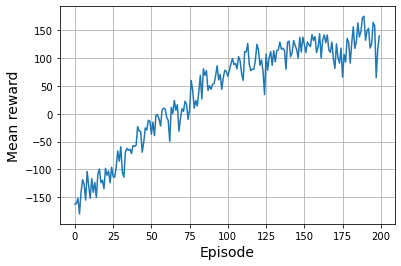

In [ ]:
plt.plot(mean_rewards)
plt.xlabel("Episode")
plt.ylabel("Mean reward")
plt.grid()
plt.show()

Now let's look at the result!

In [ ]:
def lander_render_policy_net(model, n_max_steps=500, seed=42):
    frames = []
    env = gym.make("LunarLander-v3", render_mode="rgb_array")
    tf.random.set_seed(seed)
    np.random.seed(seed)
    obs, info = env.reset(seed=seed)
    for step in range(n_max_steps):
        frames.append(env.render())
        probas = model(obs[np.newaxis])
        logits = tf.math.log(probas + tf.keras.backend.epsilon())
        action = tf.random.categorical(logits, num_samples=1)
        obs, reward, done, truncated, info = env.step(action[0, 0].numpy())
        if done or truncated:
            break
    env.close()
    return frames

In [ ]:
frames = lander_render_policy_net(model, seed=42)
plot_animation(frames)

That's pretty good. You can try training it for longer and/or tweaking the hyperparameters to see if you can get it to go over 200.

## 9.
_Exercise: Use a Double Dueling DQN to train an agent that can achieve a superhuman level at the famous Atari Breakout game (`"ALE/Breakout-v5"`). The observations are images. To simplify the task, you should convert them to grayscale (i.e., average over the channels axis), crop them and downsample them, so they're just large enough to play, but not much more. An individual image does not tell you which way the ball and the paddles are going, so you should merge two or three consecutive images to form each state. Lastly, the DQN should be composed mostly of convolutional layers._

TODO

Check out the [State-of-the-Art for Atari Games on paperswithcode.com](https://paperswithcode.com/task/atari-games).

## 10.
_Exercise: If you have about $100 to spare, you can purchase a Raspberry Pi 3 plus some cheap robotics components, install TensorFlow on the Pi, and go wild! For an example, check out this [fun post](https://homl.info/2) by Lukas Biewald, or take a look at GoPiGo or BrickPi. Start with simple goals, like making the robot turn around to find the brightest angle (if it has a light sensor) or the closest object (if it has a sonar sensor), and move in that direction. Then you can start using Deep Learning: for example, if the robot has a camera, you can try to implement an object detection algorithm so it detects people and moves toward them. You can also try to use RL to make the agent learn on its own how to use the motors to achieve that goal. Have fun!_

It's your turn now: go crazy, be creative, but most of all, be patient and move forward step by step, you can do it!